In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from skimage import io
import numpy as np
from PIL import Image, ImageOps
from mtcnn import MTCNN
from torchvision.transforms import Resize

In [3]:
import os
import requests
from PIL import Image
from io import BytesIO
from concurrent.futures import ThreadPoolExecutor, as_completed
import glob
from tqdm import tqdm
import joblib
import pickle

In [41]:
import torch

In [44]:
from mtcnn import MTCNN
detector = MTCNN()

# FUNCTIONS

In [4]:
def download_image(row, folder):
    image_name = row['name']
    url = row['url']

    try:
        response = requests.get(url, timeout=10)
        response.raise_for_status()
        image = Image.open(BytesIO(response.content))
        image.save(f"{folder}/{image_name}")
        return True
    except Exception as e:
        return False

In [5]:
def download_images(df, folder="images", max_workers=20, limit=None):
    os.makedirs(folder, exist_ok=True)
    count_failed = 0

    rows = df.head(limit) if limit else df

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [executor.submit(download_image, row, folder) for _, row in rows.iterrows()]

        for i, future in enumerate(as_completed(futures), start=1):
            if not future.result():
                count_failed += 1
            if i % 1000 == 0:
                print(f"Downloaded: {i}, Failed: {count_failed}")

    print('Total:', len(rows), 'Failed:', count_failed)
    return rows

In [45]:
#This function detects faces and cuts the image to avoid noise and turns and transforms images to Grayscale
#It also brings all images to the same size (adding padding if necessary)


def preprocess_image(image, target_size=(48, 48), margin=20):
    if image is None:
        return None

    # Ensure image is in RGB format for MTCNN
    image_rgb = image.convert("RGB")
    image_array = np.array(image_rgb)

    # Detect faces using MTCNN
    detection = detector.detect_faces(image_array)
    if not detection:
        print("No face detected.")
        return None

    # Use the first detected face
    x, y, width, height = detection[0]['box']

    # Add margin
    x = max(0, x - margin)
    y = max(0, y - margin)
    width = width + 2 * margin
    height = height + 2 * margin

    # Crop from original image (which can be RGB or grayscale at this point)
    cropped_face = image.crop((x, y, x + width, y + height))

    # Convert to grayscale
    grayscale_face = cropped_face.convert('L')

    # Resize and pad to target size
    resized_face = ImageOps.pad(
        grayscale_face,
        target_size,
        method=Image.Resampling.LANCZOS,
        color=0,
        centering=(0.5, 0.5)
    )

    return resized_face

In [39]:
def load_local_images_to_dataframe(df, folder="images", processed_folder="processed_images", max_workers=8):
    """
    Loads, preprocesses, and saves images from a local folder using multithreading.
    Displays a tqdm progress bar.
    Returns a DataFrame with 'name', 'processed_image', and 'processed_path' columns.
    """

    os.makedirs(processed_folder, exist_ok=True)

    def load_and_preprocess(name):
        try:
            image_path = os.path.join(folder, name)
            with Image.open(image_path) as img:
                img.load()
                img_copy = img.copy()
            processed = preprocess_image(img_copy)
            if processed is not None:
                processed_name = os.path.splitext(name)[0] + ".png"  # or just use name
                save_path = os.path.join(processed_folder, processed_name)
                processed.save(save_path)
                return {
                    'name': name,
                    'processed_image': processed,
                    'processed_path': save_path
                }
        except Exception as e:
            # Optional: log error
            pass
        return None


    results = []
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = {executor.submit(load_and_preprocess, name): name for name in df['name']}
        for future in tqdm(as_completed(futures), total=len(futures), desc="Processing images"):
            result = future.result()
            if result is not None:
                results.append(result)

    return pd.DataFrame(results)

In [8]:
def display_images_with_labels(urls, labels, rows=4, cols=5):
    """
    Display images from a list of URLs with their labels in subplots.

    :param urls: List of image URLs to display
    :param labels: List of corresponding labels for the images
    :param rows: Number of rows in the subplot grid
    :param cols: Number of columns in the subplot grid
    """
    fig, axes = plt.subplots(rows, cols, figsize=(15, 10))  # Adjust figure size as needed
    axes = axes.ravel()  # Flatten the axes array for easy iteration

    for i, (url, label) in enumerate(zip(urls, labels)):
        try:
            img = io.imread(url)
            axes[i].imshow(img)
            axes[i].set_title(f"{label}", fontsize=10)
            axes[i].axis('off')
        except Exception as e:
            axes[i].axis('off')
            axes[i].set_title("Error")
            print(f"Could not fetch image at index {i}: {e}")

    # Hide any unused subplots
    for j in range(len(urls), len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# READING & PREPARING DATA

In [11]:
file_path = 'training_raw_data.json'

In [12]:
df = pd.read_json(file_path)

In [13]:
label_counts = df['label'].value_counts()

# Calculate the proportion of each label
label_proportions = label_counts / len(df)

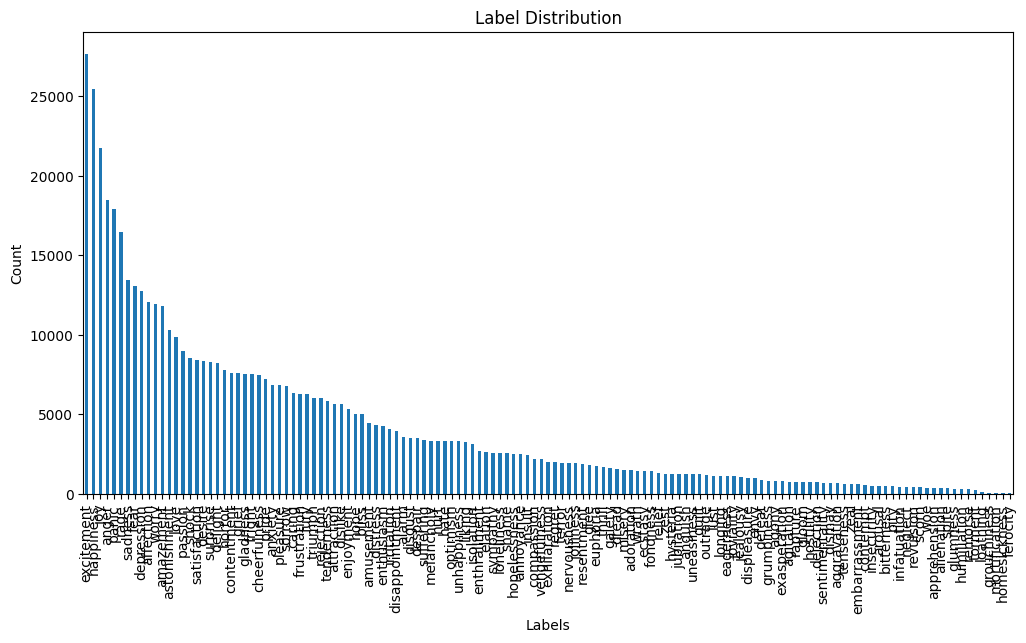

In [14]:
plt.figure(figsize=(12, 6))
label_counts.plot(kind='bar')
plt.title('Label Distribution')
plt.xlabel('Labels')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

### Comment

The dataset is not balance. We will merge some similar categories to obtain balanced dataset. (To be done after downloading)

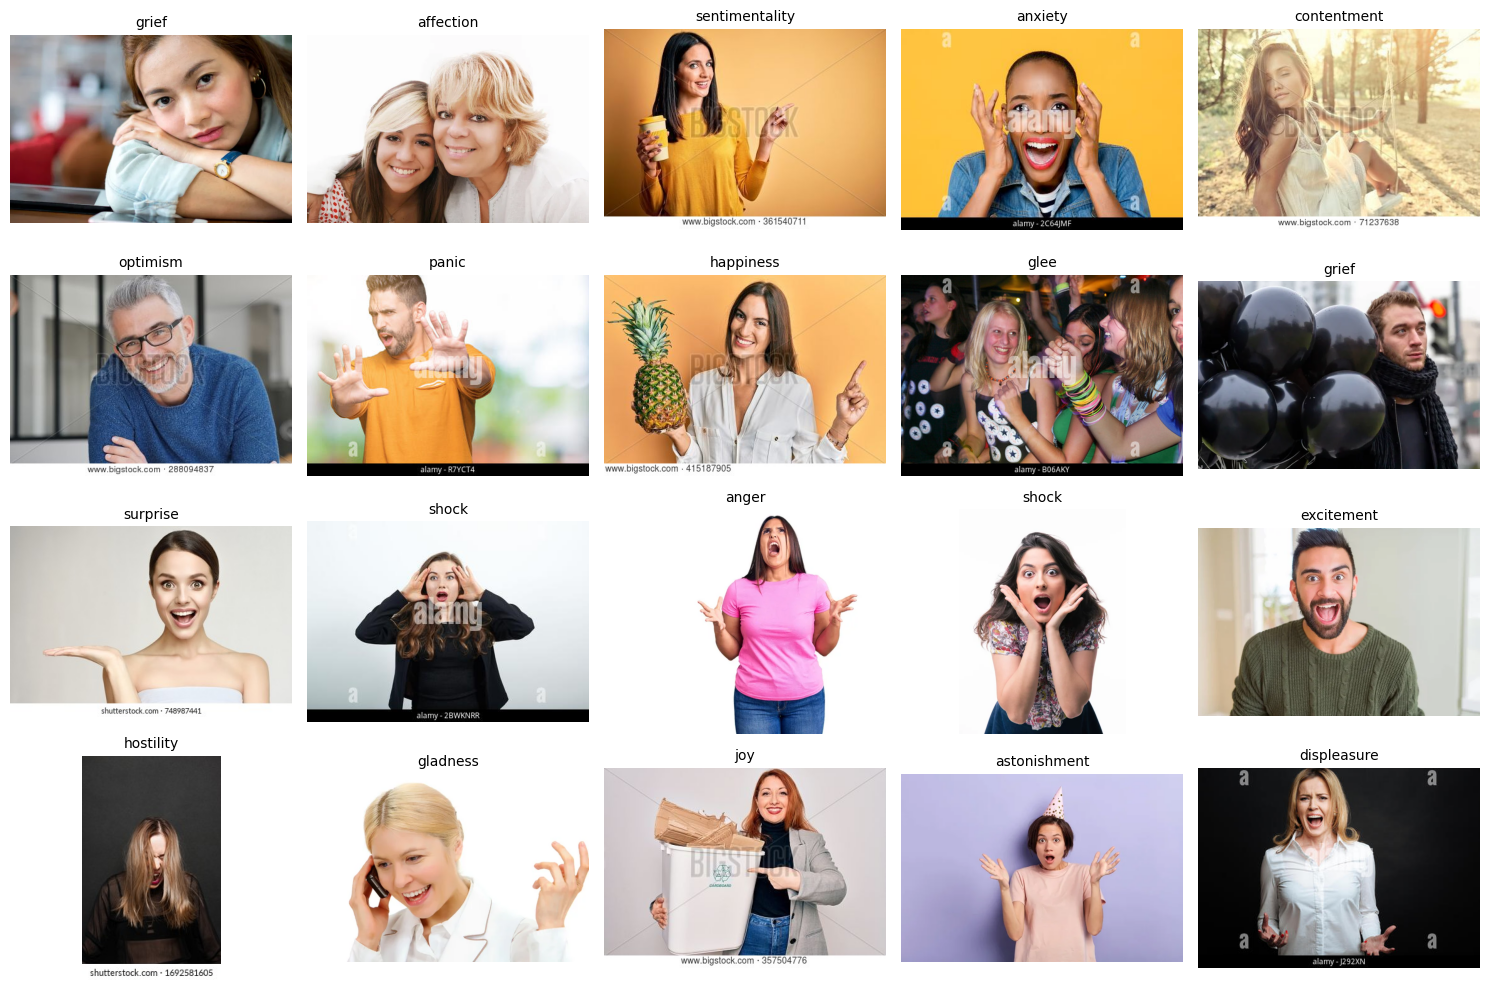

In [15]:
# Display images with labels

sample = df.sample(20)

# Extract URLs and labels
sample_urls = sample['url'].tolist()
sample_labels = sample['label'].tolist()

display_images_with_labels(sample_urls, sample_labels, rows=4, cols=5)

### Comment

The pictures will need additional additional processing: 
- Detecting face
- cutting the image
- changing to grey scale
- adding padding

## Downloading the images from url to local folder

In [16]:
labels = df['label'].unique()

In [17]:
df_with_downloaded_images = pd.DataFrame()

for l in tqdm(labels, desc="Processing labels"):
    print(l)
    df_temp = df[df['label']==l]
    df_downloaded_temp = download_images(df_temp)
    df_with_images_temp = load_local_images_to_dataframe(df_downloaded_temp)
    df_with_images_temp = df_with_images_temp.dropna()
    
    df_with_downloaded_images = pd.concat([df_with_downloaded_images, df_with_images_temp], ignore_index = True)

Processing labels:   0%|          | 0/135 [00:00<?, ?it/s]

adoration
Downloaded: 1000, Failed: 4
Total: 1474 Failed: 7


Processing labels:   1%|          | 1/135 [00:28<1:03:23, 28.39s/it]

affection
Downloaded: 1000, Failed: 47
Downloaded: 2000, Failed: 65
Downloaded: 3000, Failed: 67
Downloaded: 4000, Failed: 924
Downloaded: 5000, Failed: 1924
Downloaded: 6000, Failed: 2924
Downloaded: 7000, Failed: 3924
Downloaded: 8000, Failed: 4924
Downloaded: 9000, Failed: 5924
Downloaded: 10000, Failed: 6924
Downloaded: 11000, Failed: 7924
Downloaded: 12000, Failed: 8924
Total: 12060 Failed: 8984


Processing labels:   1%|▏         | 2/135 [02:55<3:38:09, 98.42s/it]

...

Processing labels:  99%|█████████▊| 133/135 [1:59:53<01:18, 39.33s/it]

zeal
Total: 621 Failed: 0


Processing labels:  99%|█████████▉| 134/135 [2:00:00<00:29, 29.54s/it]

zest
Downloaded: 1000, Failed: 3
Total: 1272 Failed: 3


Processing labels: 100%|██████████| 135/135 [2:00:14<00:00, 53.44s/it]


In [30]:
# getting all names of the files which were successfully downloaded
downloaded = set(os.listdir('images'))

In [31]:
downloaded

{'bigstockphoto_passion_look_1800_43.jpg',
 'alamy_amazement_emotion_4_8.jpg',
 'shutterstock_disgust_look_1_63.jpg',
 'shutterstock_suffering_portrait_3_79.jpg',
 'bigstockphoto_amazement_expression_450_130.jpg',
 'bigstockphoto_surprise_face_1650_86.jpg',
 'shutterstock_insult_portrait_11_38.jpg',
 'bigstockphoto_annoyance_expression_900_114.jpg',
 'bigstockphoto_enthrallment_portrait_150_136.jpg',
 'bigstockphoto_amazement_expression_1800_136.jpg',
 'alamy_desire_portrait_1_74.jpg',
 'alamy_euphoria_portrait_8_7.jpg',
 'shutterstock_hysteria_look_8_12.jpg',
 'alamy_irritation_portrait_13_70.jpg',
 'shutterstock_relief_portrait_1_3.jpg',
 'bigstockphoto_passion_portrait_1350_57.jpg',
 'alamy_irritation_portrait_6_44.jpg',
 'bigstockphoto_despair_portrait_1500_47.jpg',
 'bigstockphoto_disgust_face_600_145.jpg',
 'alamy_anger_expression_12_91.jpg',
 'alamy_contentment_face_2_90.jpg',
 'alamy_cheerfulness_portrait_5_65.jpg',
 'bigstockphoto_astonishment_portrait_450_13.jpg',
 'alamy_wra

In [46]:
df_with_downloaded_images = df[df['name'].isin(downloaded)].reset_index(drop=True)

In [ ]:
df_processed = load_local_images_to_dataframe(df_with_downloaded_images)

Processing images:   0%|          | 0/269178 [00:00<?, ?it/s]

3/3 [==============================] - 0s 11ms/step


Processing images:   0%|          | 1/269178 [00:03<266:58:59,  3.57s/it]

No face detected.
1/1 [==============================] - ETA: 0s

Processing images:   0%|          | 2/269178 [00:04<133:57:29,  1.79s/it]

...

Processing images:   1%|          | 2065/269178 [17:21<19:00:42,  3.90it/s]

2/2 [==============================] - 0s 14ms/step


Processing images:   1%|          | 2065/269178 [17:23<37:29:23,  1.98it/s]

1/1 [==============================] - 0s 40ms/step


1/1 [==============================] - 0s 63ms/step
No face detected.
1/1 [==============================] - ETA: 0s

In [ ]:
# filtering the dataframe, so that it only included successfully downloaded images

# df_with_downloaded_images = df_with_downloaded_images[df_with_downloaded_images['name'].isin(downloaded)].reset_index(drop=True) 
df_with_downloaded_images = df[df['name'].isin(downloaded)].reset_index(drop=True) #shortcut in case you skipped download from url and want to load from local folder

6:57

In [37]:
df_with_downloaded_images.head()

,name,url,description,label
0,shutterstock_adoration_portrait_4_9.jpg,https://image.shutterstock.com/image-photo/lov...,Lovely Middleaged Blond Woman Beaming Smile St...,adoration
1,shutterstock_adoration_expression_1_76.jpg,https://image.shutterstock.com/image-photo/por...,Portrait Young Happy Positive Good Mood Stock ...,adoration
2,alamy_adoration_portrait_5_67.jpg,https://h7.alamy.com/zooms/6/9b4f27dbc0964952b...,Amused speechless cute redhead young girl with...,adoration
3,shutterstock_adoration_expression_1_29.jpg,https://image.shutterstock.com/image-photo/pho...,Photo Portrait Girl Smiling Cute Overjoyed Sto...,adoration
4,alamy_adoration_portrait_1_36.jpg,https://h7.alamy.com/zooms/6/c26127195f4a4fca9...,Portrait of five smiling friends,adoration


# Processing the images

## BALANCING THE DATASET

##  Grouping labels into 14 categories  

In [ ]:
label_to_category = {
    # Neutral / Not Engaged
    "neutral": "Neutral / Not Engaged", "neglect":"Neutral / Not Engaged", "isolation": "Neutral / Not Engaged",

    # Joy / Positive Engagement
    "happy": "Joy / Positive Engagement", "happiness": "Joy / Positive Engagement",
    "cheerfulness": "Joy / Positive Engagement", "joy": "Joy / Positive Engagement",
    "delight": "Joy / Positive Engagement", "gladness": "Joy / Positive Engagement",
    "pleasure": "Joy / Positive Engagement", "enjoyment": "Joy / Positive Engagement",
    "jolliness": "Joy / Positive Engagement", "glee": "Joy / Positive Engagement",
    "bliss": "Joy / Positive Engagement", "exhilaration": "Joy / Positive Engagement",
    "elation": "Joy / Positive Engagement", "euphoria": "Joy / Positive Engagement",
    "gaiety": "Joy / Positive Engagement", "jubilation": "Joy / Positive Engagement",
    "ecstasy": "Joy / Positive Engagement", "joviality": "Joy / Positive Engagement",
    "rapture": "Joy / Positive Engagement", "zest": "Joy / Positive Engagement",

    # Surprise / Amazement
    "surprise": "Surprise / Amazement", "shock": "Surprise / Amazement",
    "astonishment": "Surprise / Amazement", "amazement": "Surprise / Amazement",
    "thrill": "Surprise / Amazement", "enthusiasm": "Surprise / Amazement",
    "exhilaration": "Surprise / Amazement", "enthrallment": "Surprise / Amazement",
    "amusement": "Surprise / Amazement",
    
    # Interest / Engagement
    "excitement": "Interest / Engagement", "interest": "Interest / Engagement",
    "attraction": "Interest / Engagement", "liking": "Interest / Engagement",
    "arousal": "Interest / Engagement", "eagerness": "Interest / Engagement",
    "zeal": "Interest / Engagement", "curiosity": "Interest / Engagement",
    "hope": "Interest / Engagement", "optimism": "Interest / Engagement",

    # Love / Affection / Caring
    "love": "Love / Affection / Caring", "affection": "Love / Affection / Caring",
    "tenderness": "Love / Affection / Caring", "caring": "Love / Affection / Caring",
    "compassion": "Love / Affection / Caring", "fondness": "Love / Affection / Caring",
    "adoration": "Love / Affection / Caring", "sentimentality": "Love / Affection / Caring",
    "sympathy": "Love / Affection / Caring", "pity": "Love / Affection / Caring",
    "infatuation": "Love / Affection / Caring",

    # Pride / Accomplishment
    "triumph": "Pride / Accomplishment", "pride": "Pride / Accomplishment",
    "satisfaction": "Pride / Accomplishment", "contentment": "Pride / Accomplishment",
    "relief": "Pride / Accomplishment", "pleasure": "Pride / Accomplishment",

    # Desire / Passion
    "desire": "Desire / Passion", "passion": "Desire / Passion",
    "longing": "Desire / Passion", "lust": "Desire / Passion",
    "infatuation": "Desire / Passion",

    # Anger / Irritation
    "anger": "Anger / Irritation", "angry": "Anger / Irritation",
    "rage": "Anger / Irritation", "wrath": "Anger / Irritation",
    "frustration": "Anger / Irritation", "resentment": "Anger / Irritation",
    "annoyance": "Anger / Irritation", "exasperation": "Anger / Irritation",
    "fury": "Anger / Irritation", "aggravation": "Anger / Irritation",
    "outrage": "Anger / Irritation", "grumpiness": "Anger / Irritation",
    "hostility": "Anger / Irritation", "grouchiness": "Anger / Irritation",
    "spite": "Anger / Irritation", "ferocity": "Anger / Irritation",
    "vengefulness": "Anger / Irritation", "irritation":"Anger / Irritation",

    # Fear / Anxiety
    "fear": "Fear / Anxiety", "panic": "Fear / Anxiety", "worry": "Fear / Anxiety",
    "horror": "Fear / Anxiety", "alarm": "Fear / Anxiety", "dread": "Fear / Anxiety",
    "fright": "Fear / Anxiety", "terror": "Fear / Anxiety", "nervousness": "Fear / Anxiety",
    "apprehension": "Fear / Anxiety", "uneasiness": "Fear / Anxiety",
    "tenseness": "Fear / Anxiety", "anxiety": "Fear / Anxiety", "dismay": "Fear / Anxiety",
    "hysteria": "Fear / Anxiety",

    # Sadness / Grief
    "sad": "Sadness / Grief", "sadness": "Sadness / Grief", "sorrow": "Sadness / Grief",
    "melancholy": "Sadness / Grief", "despair": "Sadness / Grief",
    "depression": "Sadness / Grief", "grief": "Sadness / Grief",
    "hopelessness": "Sadness / Grief", "misery": "Sadness / Grief",
    "dejection": "Sadness / Grief", "gloom": "Sadness / Grief",
    "woe": "Sadness / Grief", "glumness": "Sadness / Grief", "homesickness": "Sadness / Grief",

    # Disgust / Aversion
    "disgust": "Disgust / Aversion", "revulsion": "Disgust / Aversion",
    "loathing": "Disgust / Aversion", "displeasure": "Disgust / Aversion",
    "contempt": "Disgust / Aversion", "scorn": "Disgust / Aversion",
    "dislike": "Disgust / Aversion", "hate": "Disgust / Aversion",
    "bitterness": "Disgust / Aversion", "envy": "Disgust / Aversion",
    "jealousy": "Disgust / Aversion",

    # Shame / Guilt / Embarrassment
    "shame": "Shame / Guilt / Embarrassment", "guilt": "Shame / Guilt / Embarrassment",
    "regret": "Shame / Guilt / Embarrassment", "remorse": "Shame / Guilt / Embarrassment",
    "humiliation": "Shame / Guilt / Embarrassment", "embarrassment": "Shame / Guilt / Embarrassment",
    "mortification": "Shame / Guilt / Embarrassment",


    # Hurt / Pain / Suffering
    "hurt": "Hurt / Pain / Suffering", "suffering": "Hurt / Pain / Suffering",
    "torment": "Hurt / Pain / Suffering", "anguish": "Hurt / Pain / Suffering",
    "agony": "Hurt / Pain / Suffering", "distress": "Hurt / Pain / Suffering",
    "insecurity": "Hurt / Pain / Suffering", "defeat": "Hurt / Pain / Suffering",
    "pain": "Hurt / Pain / Suffering",

    # Disengagement / Negative Mood
    "disappointment": "Disengagement / Negative Mood", "unhappiness": "Disengagement / Negative Mood",
    "agitation": "Disengagement / Negative Mood", "gloom": "Disengagement / Negative Mood",
    "defeat": "Disengagement / Negative Mood", "rejection": "Disengagement / Negative Mood", "alienation":"Disengagement / Negative Mood", 
    "loneliness":"Disengagement / Negative Mood", "insult":"Disengagement / Negative Mood"
}


In [ ]:
# Apply mapping
df_with_processed_images['emotion_category'] = df_with_processed_images['label'].map(label_to_category)

# Checking if there are any unmapped labels
unmapped = df_with_processed_images[df_with_processed_images['emotion_category'].isna()]['label'].unique()
print("Unmapped labels:", unmapped)

In [ ]:
label_counts = df_with_processed_images['emotion_category'].value_counts()

# Calculate the proportion of each label
label_proportions = label_counts / len(df_with_processed_images)

In [ ]:
# Pie chart of label proportions
plt.figure(figsize=(8, 8))
label_proportions.plot(kind='pie', autopct='%1.1f%%')
plt.title('Emotion Category Proportion')
plt.ylabel('')  # Hide the default y-label
plt.show()

### Downsampling the major lables 

In [ ]:
from sklearn.utils import resample

balanced_df_list = []

min_count = df_with_processed_images['emotion_category'].value_counts().min()

for category in df_with_processed_images['emotion_category'].unique():
    subset = df_with_processed_images[df_with_processed_images['emotion_category'] == category]
    downsampled = resample(subset, replace=False, n_samples=min_count, random_state=42)
    balanced_df_list.append(downsampled)

balanced_df = pd.concat(balanced_df_list)

In [ ]:
joblib.dump(balanced_df, "df_balanced_to_export.pkl", compress=0)